In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

ordner = "/content/Daten"
dateien = glob.glob(os.path.join(ordner, "*.csv"))

df_liste = []

for datei in dateien:
    df_temp = pd.read_csv(datei, engine="python", on_bad_lines="skip", sep=";")
    df_temp["quelle_datei"] = os.path.basename(datei)
    df_liste.append(df_temp)

df = pd.concat(df_liste, ignore_index=True)

print(df.head())
print(df.info())

  english_term spanish_term  migrationsbezug_eng  migrationsbezug_spa  \
0     A-Number     Número A                    1                    1   
1     A-Number     Número A                    1                    1   
2     A-Number     Número A                    1                    1   
3     A-Number     Número A                    1                    1   
4     A-Number     Número A                    1                    1   

   polysemie_eng  polysemie_spa  topic_number  \
0              0              0             3   
1              0              0             3   
2              0              0             3   
3              0              0             3   
4              0              0             3   

                                topic  migrationsbezug_equal  \
0  Dokument, Visa, formelle Nachweise                      1   
1  Dokument, Visa, formelle Nachweise                      1   
2  Dokument, Visa, formelle Nachweise                      1   
3  Dokumen

In [2]:
clean_df = df[
    ~(
        (
            (df['qs_eng'].notna() & df['qs_migrationsbezug_eng_final'].isna()) |
            (df['qs_spa'].notna() & df['qs_migrationsbezug_spa_final'].isna())
        )
        |
        (df['english_term'] == "Naturalization certificate")
        |
         (df['english_term'] == "Petitioner")
        |
         (df['english_term'] == "Smuggling of migrants")
        |
         (df['english_term'] == "foreigner")

    )
].copy()

In [3]:
print(clean_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 266698 entries, 0 to 271238
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   english_term                  266698 non-null  object 
 1   spanish_term                  266698 non-null  object 
 2   migrationsbezug_eng           266698 non-null  int64  
 3   migrationsbezug_spa           266698 non-null  int64  
 4   polysemie_eng                 266698 non-null  int64  
 5   polysemie_spa                 266698 non-null  int64  
 6   topic_number                  266698 non-null  int64  
 7   topic                         266698 non-null  object 
 8   migrationsbezug_equal         266698 non-null  int64  
 9   migrationsbezug_any           266698 non-null  int64  
 10  migrationsbezug_both          266698 non-null  int64  
 11  qs_position                   266698 non-null  int64  
 12  qs_eng                        265445 non-null  ob

In [4]:
import pandas as pd

df = clean_df.copy()

# Sicherheit: numerisch
df['qs_migrationsbezug_eng_final'] = pd.to_numeric(df['qs_migrationsbezug_eng_final'], errors='coerce')
df['qs_migrationsbezug_spa_final'] = pd.to_numeric(df['qs_migrationsbezug_spa_final'], errors='coerce')

# Englisch
mean_eng = df[
    df['qs_migrationsbezug_eng_final'].notna()
]['qs_migrationsbezug_eng_final'].mean() * 100

# Spanisch
mean_spa = df[
    df['qs_migrationsbezug_spa_final'].notna()
]['qs_migrationsbezug_spa_final'].mean() * 100

print(f"Englisch: {mean_eng:.2f}%")
print(f"Spanisch: {mean_spa:.2f}%")

Englisch: 38.86%
Spanisch: 35.29%


Prozentwerte für den Plot:
                                                     Englisch   Spanisch
Query Suggestions für Suchterme MIT Migrationsb...  77.427954  74.582181
Query Suggestions für Suchterme OHNE Migrations...   6.848692   5.389637

Absolute Zahlen + Prozente:
    Sprache                          Gruppe  n = Gesamtzahl QS  \
0  Englisch   Suchterme MIT Migrationsbezug             120410   
1  Spanisch   Suchterme MIT Migrationsbezug              99804   
2  Englisch  Suchterme OHNE Migrationsbezug             145035   
3  Spanisch  Suchterme OHNE Migrationsbezug             131122   

   davon migrationsbezogen (absolut)  davon nicht migrationsbezogen (absolut)  \
0                              93231                                    27179   
1                              74436                                    25368   
2                               9933                                   135102   
3                               7067                                  

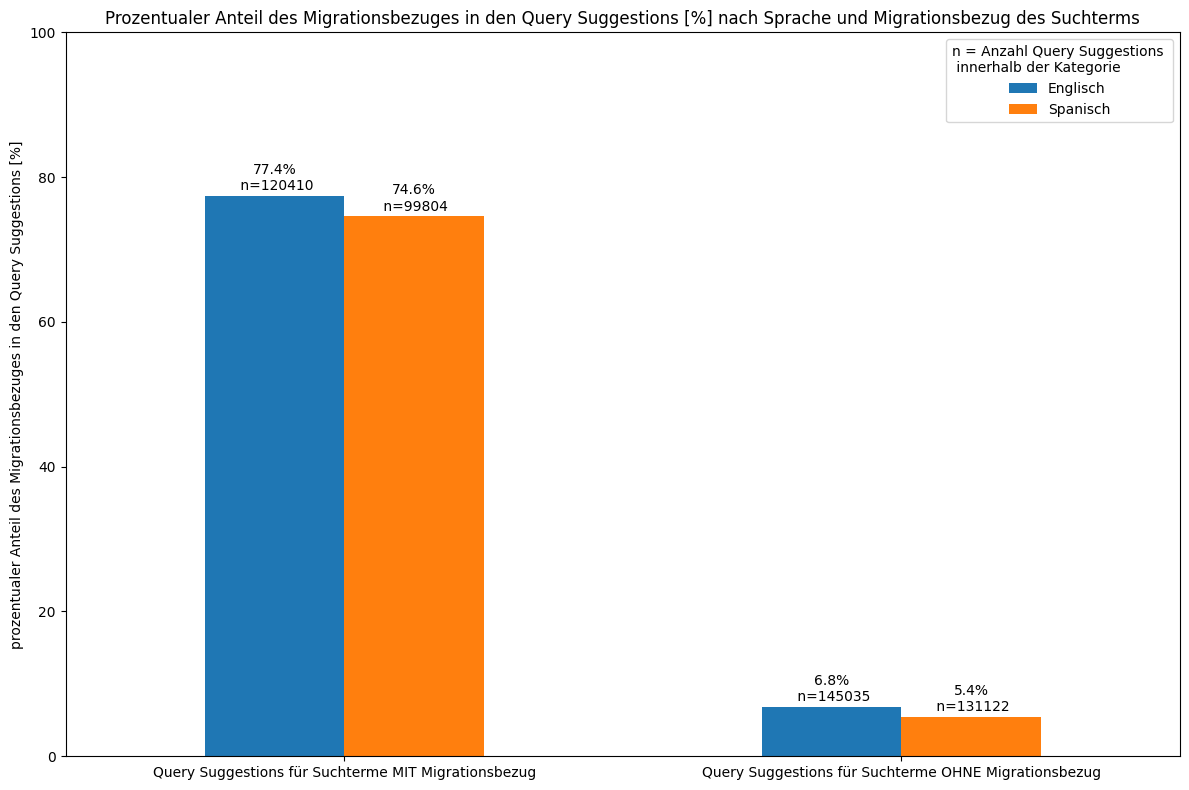

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Ausgangsbasis
# ------------------------------------------------------------
df = clean_df.copy()

# Sicherheit: numerisch
for col in [
    'qs_migrationsbezug_eng_final',
    'qs_migrationsbezug_spa_final',
    'migrationsbezug_eng',
    'migrationsbezug_spa'
]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ------------------------------------------------------------
# Funktion: Prozent + absolute Zahlen
# ------------------------------------------------------------
def compute_qs_migration_stats(df, term_migration_flag):
    """
    term_migration_flag:
        1 = Suchterme MIT Migrationsbezug
        0 = Suchterme OHNE Migrationsbezug

    Gibt zurück:
    - total = alle gültigen QS in der Gruppe (= 100 %)
    - mig = migrationsbezogene QS absolut
    - non_mig = nicht migrationsbezogene QS absolut
    - pct = Anteil migrationsbezogener QS in %
    """

    # Englisch
    eng_subset = df[
        (df['english_term'].notna()) &
        (df['qs_eng'].notna()) &
        (df['qs_migrationsbezug_eng_final'].notna()) &
        (df['migrationsbezug_eng'] == term_migration_flag)
    ].copy()

    eng_total = len(eng_subset)
    eng_mig = int(eng_subset['qs_migrationsbezug_eng_final'].sum())
    eng_non_mig = eng_total - eng_mig
    eng_pct = (eng_mig / eng_total * 100) if eng_total > 0 else 0

    # Spanisch
    spa_subset = df[
        (df['spanish_term'].notna()) &
        (df['qs_spa'].notna()) &
        (df['qs_migrationsbezug_spa_final'].notna()) &
        (df['migrationsbezug_spa'] == term_migration_flag)
    ].copy()

    spa_total = len(spa_subset)
    spa_mig = int(spa_subset['qs_migrationsbezug_spa_final'].sum())
    spa_non_mig = spa_total - spa_mig
    spa_pct = (spa_mig / spa_total * 100) if spa_total > 0 else 0

    return {
        'eng_total': eng_total,
        'eng_mig': eng_mig,
        'eng_non_mig': eng_non_mig,
        'eng_pct': eng_pct,
        'spa_total': spa_total,
        'spa_mig': spa_mig,
        'spa_non_mig': spa_non_mig,
        'spa_pct': spa_pct
    }

# ------------------------------------------------------------
# Werte berechnen
# ------------------------------------------------------------
with_stats = compute_qs_migration_stats(df, 1)
without_stats = compute_qs_migration_stats(df, 0)

# ------------------------------------------------------------
# Tabelle mit Prozenten für Plot
# ------------------------------------------------------------
plot_df = pd.DataFrame({
    'Englisch': [with_stats['eng_pct'], without_stats['eng_pct']],
    'Spanisch': [with_stats['spa_pct'], without_stats['spa_pct']]
}, index=[
    'Query Suggestions für Suchterme MIT Migrationsbezug',
    'Query Suggestions für Suchterme OHNE Migrationsbezug'
])

print("Prozentwerte für den Plot:")
print(plot_df)
print()

# ------------------------------------------------------------
# Tabelle mit absoluten Zahlen
# ------------------------------------------------------------
abs_df = pd.DataFrame({
    'Sprache': ['Englisch', 'Spanisch', 'Englisch', 'Spanisch'],
    'Gruppe': [
        'Suchterme MIT Migrationsbezug',
        'Suchterme MIT Migrationsbezug',
        'Suchterme OHNE Migrationsbezug',
        'Suchterme OHNE Migrationsbezug'
    ],
    'n = Gesamtzahl QS': [
        with_stats['eng_total'],
        with_stats['spa_total'],
        without_stats['eng_total'],
        without_stats['spa_total']
    ],
    'davon migrationsbezogen (absolut)': [
        with_stats['eng_mig'],
        with_stats['spa_mig'],
        without_stats['eng_mig'],
        without_stats['spa_mig']
    ],
    'davon nicht migrationsbezogen (absolut)': [
        with_stats['eng_non_mig'],
        with_stats['spa_non_mig'],
        without_stats['eng_non_mig'],
        without_stats['spa_non_mig']
    ],
    'Anteil migrationsbezogen (%)': [
        with_stats['eng_pct'],
        with_stats['spa_pct'],
        without_stats['eng_pct'],
        without_stats['spa_pct']
    ]
})

print("Absolute Zahlen + Prozente:")
print(abs_df)
print()

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
ax = plot_df.plot(kind='bar', figsize=(12, 8))

plt.ylabel('prozentualer Anteil des Migrationsbezuges in den Query Suggestions [%]')
plt.xlabel('')
plt.ylim(0, 100)
plt.title('Prozentualer Anteil des Migrationsbezuges in den Query Suggestions [%] nach Sprache und Migrationsbezug des Suchterms')

plt.xticks(rotation=0)
plt.legend(title='n = Anzahl Query Suggestions \n innerhalb der Kategorie')

# Labels mit Prozent + n
for i, container in enumerate(ax.containers):
    labels = []
    for j, bar in enumerate(container):
        if i == 0:  # Englisch
            total = with_stats['eng_total'] if j == 0 else without_stats['eng_total']
        else:       # Spanisch
            total = with_stats['spa_total'] if j == 0 else without_stats['spa_total']

        labels.append(f"{bar.get_height():.1f}%\n n={total}")

    ax.bar_label(container, labels=labels, padding=2)

plt.tight_layout()
plt.show()

In [12]:
# Anteil pro Term berechnen
term_level_eng = clean_df.groupby('english_term')['qs_migrationsbezug_eng_final'].mean()
term_level_spa = clean_df.groupby('spanish_term')['qs_migrationsbezug_spa_final'].mean()

# dann Mittelwert über Terme
print(term_level_eng.mean())
print(term_level_spa.mean())

0.3953045914829986
0.36905558150874473


In [13]:
eng_with_term = clean_df[clean_df['migrationsbezug_eng'] == 1] \
    .groupby('english_term')['qs_migrationsbezug_eng_final'].mean().mean()

spa_with_term = clean_df[clean_df['migrationsbezug_spa'] == 1] \
    .groupby('spanish_term')['qs_migrationsbezug_spa_final'].mean().mean()

In [14]:
eng_without_term = clean_df[clean_df['migrationsbezug_eng'] == 0] \
    .groupby('english_term')['qs_migrationsbezug_eng_final'].mean().mean()

spa_without_term = clean_df[clean_df['migrationsbezug_spa'] == 0] \
    .groupby('spanish_term')['qs_migrationsbezug_spa_final'].mean().mean()

In [15]:
print("Term-Level Ergebnisse:")

print("\nMIT Migrationsbezug:")
print(f"Englisch:  {eng_with_term:.3f}")
print(f"Spanisch:  {spa_with_term:.3f}")

print("\nOHNE Migrationsbezug:")
print(f"Englisch:  {eng_without_term:.3f}")
print(f"Spanisch:  {spa_without_term:.3f}")

Term-Level Ergebnisse:

MIT Migrationsbezug:
Englisch:  0.775
Spanisch:  0.736

OHNE Migrationsbezug:
Englisch:  0.069
Spanisch:  0.053


In [6]:
import pandas as pd
import numpy as np
from itertools import combinations

def compute_jaccard_by_term(df, lang, migration_flag):
    """
    lang: 'eng' oder 'spa'
    migration_flag: 1 (mit) oder 0 (ohne)
    """

    qs_col = f'qs_{lang}'
    term_col = 'english_term' if lang == 'eng' else 'spanish_term'
    term_mig_col = f'migrationsbezug_{lang}'

    subset = df[
        (df[qs_col].notna()) &
        (df[term_col].notna()) &
        (df[term_mig_col].notna()) &
        (df[term_mig_col] == migration_flag)
    ].copy()

    # Standort-ID
    subset['location_id'] = (
        subset['land'].astype(str) + " | " +
        subset['bundesstaat'].astype(str) + " | " +
        subset['stadt'].astype(str)
    )

    # Sets pro Term & Standort
    term_location_sets = (
        subset.groupby([term_col, 'location_id'])[qs_col]
        .apply(lambda x: set(x.dropna().astype(str).str.strip()))
        .reset_index(name='qs_set')
    )

    # Pairwise Jaccard
    results = []

    for term, group in term_location_sets.groupby(term_col):
        location_sets = list(zip(group['location_id'], group['qs_set']))

        if len(location_sets) < 2:
            continue

        for (_, set1), (_, set2) in combinations(location_sets, 2):
            union = set1 | set2
            if len(union) == 0:
                score = np.nan
            else:
                score = len(set1 & set2) / len(union)

            results.append(score)

    return pd.Series(results, name=f'{lang}_{migration_flag}')

In [7]:
# Englisch
eng_with = compute_jaccard_by_term(clean_df, 'eng', 1)
eng_without = compute_jaccard_by_term(clean_df, 'eng', 0)

# Spanisch
spa_with = compute_jaccard_by_term(clean_df, 'spa', 1)
spa_without = compute_jaccard_by_term(clean_df, 'spa', 0)

In [9]:
def compute_avg_set_size(df, lang, migration_flag):

    qs_col = f'qs_{lang}'
    term_col = 'english_term' if lang == 'eng' else 'spanish_term'
    term_mig_col = f'migrationsbezug_{lang}'

    subset = df[
        (df[qs_col].notna()) &
        (df[term_col].notna()) &
        (df[term_mig_col].notna()) &
        (df[term_mig_col] == migration_flag)
    ].copy()

    subset['location_id'] = (
        subset['land'].astype(str) + " | " +
        subset['bundesstaat'].astype(str) + " | " +
        subset['stadt'].astype(str)
    )

    term_location_sets = (
        subset.groupby([term_col, 'location_id'])[qs_col]
        .apply(lambda x: set(x.dropna().astype(str).str.strip()))
        .reset_index(name='qs_set')
    )

    return term_location_sets['qs_set'].apply(len)

In [10]:
eng_with_sizes = compute_avg_set_size(clean_df, 'eng', 1)
eng_without_sizes = compute_avg_set_size(clean_df, 'eng', 0)

spa_with_sizes = compute_avg_set_size(clean_df, 'spa', 1)
spa_without_sizes = compute_avg_set_size(clean_df, 'spa', 0)

In [11]:
print("EN mit:", eng_with_sizes.mean())
print("EN ohne:", eng_without_sizes.mean())

print("ES mit:", spa_with_sizes.mean())
print("ES ohne:", spa_without_sizes.mean())

EN mit: 9.568730996959513
EN ohne: 9.937988214334657
ES mit: 7.892219387755102
ES ohne: 9.0205008255366


/tmp/ipykernel_9847/306982311.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels)


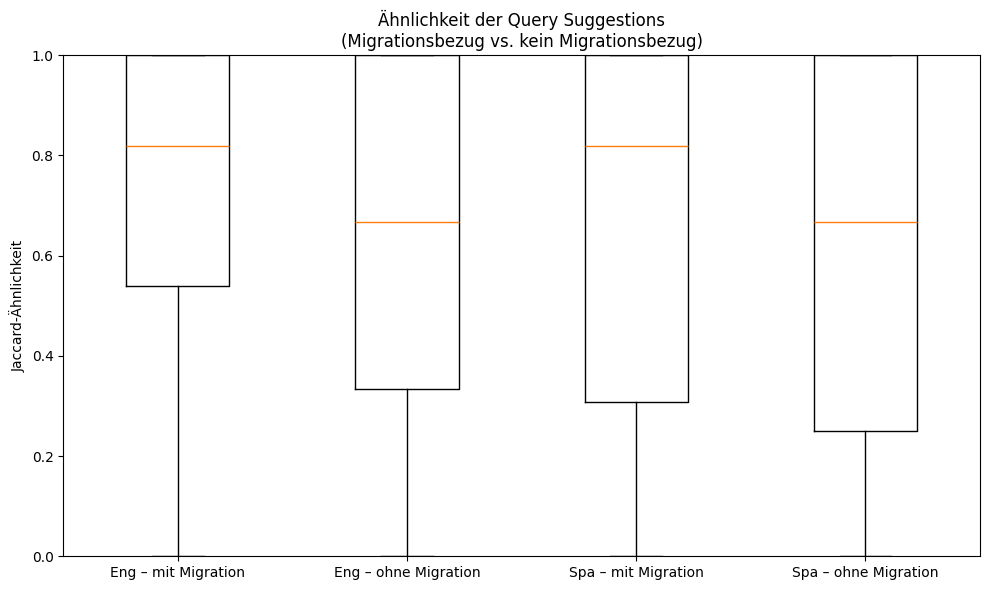

In [ ]:
import matplotlib.pyplot as plt

plot_data = [
    eng_with.dropna(),
    eng_without.dropna(),
    spa_with.dropna(),
    spa_without.dropna()
]

labels = [
    'Eng – mit Migration',
    'Eng – ohne Migration',
    'Spa – mit Migration',
    'Spa – ohne Migration'
]

plt.figure(figsize=(10, 6))
plt.boxplot(plot_data, labels=labels)

plt.ylabel('Jaccard-Ähnlichkeit')
plt.title('Ähnlichkeit der Query Suggestions\n(Migrationsbezug vs. kein Migrationsbezug)')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
#Betrachtung des durchschnittlichen Jaccard Index
print(
    "Englisch mit ", eng_with.mean(), "\n",
    "Englisch ohne ", eng_without.mean(), "\n",
    "Spanisch mit ", spa_with.mean(), "\n",
    "Spanisch ohne ", spa_without.mean()
)

Englisch mit  0.7426118732842845 
 Englisch ohne  0.6146125306692568 
 Spanisch mit  0.6546946717083079 
 Spanisch ohne  0.6021960339585051


In [ ]:
#Betrachtung des Median des Jaccard Index
print(
    "Englisch mit ", eng_with.median(), "\n",
    "Englisch ohne ", eng_without.median(), "\n",
    "Spanisch mit ", spa_with.median(), "\n",
    "Spanisch ohne ", spa_without.median()
)

Englisch mit  0.8181818181818182 
 Englisch ohne  0.6666666666666666 
 Spanisch mit  0.8181818181818182 
 Spanisch ohne  0.6666666666666666


In [ ]:
quantiles = [0.25, 0.5, 0.75]

table = pd.DataFrame({
    "Quantil": quantiles,
    "Englisch": eng_with.quantile(quantiles).values,
    "Spanisch": spa_with.quantile(quantiles).values
})

print(table)

   Quantil  Englisch  Spanisch
0     0.25  0.538462  0.307692
1     0.50  0.818182  0.818182
2     0.75  1.000000  1.000000
